### Implementing RAG

![Screenshot 2025-09-01 144429.png](<attachment:Screenshot 2025-09-01 144429.png>)
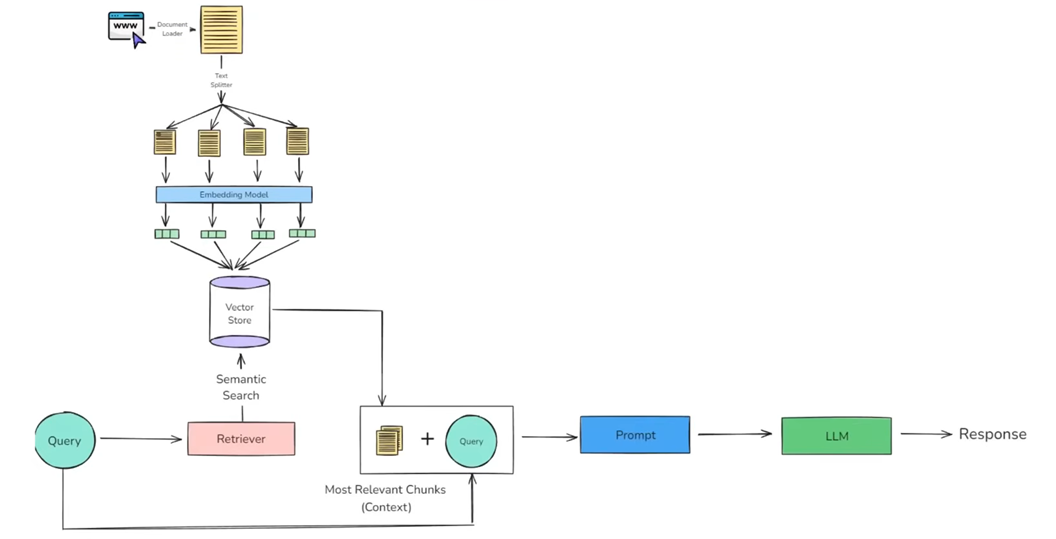

In [5]:
# libraries
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate

### Step 1a - Indexing (Document Ingestion)

library : https://pypi.org/project/youtube-transcript-api/

### transcript fetching : 


In [6]:
video_id = 'I2ZK3ngNvvI' # only the ID, not full URL

try:
    # If you don’t care which language, this returns the “best” one
    ytt_api = YouTubeTranscriptApi()
    transcript_list = ytt_api.fetch(video_id)
    # transcript_list = YouTubeTranscriptApi.get_transcript(video_id, languages = ['en'])
    
    # Flatten it to plain text
    transcript = " ".join(chunk.text for chunk in transcript_list) # joing the entire texts
    print(transcript)
    
except TranscriptsDisabled:
    print("No captions available for this video.")
except NoTranscriptFound:
    print("No transcript found in the requested language.")
except VideoUnavailable:
    print("The video is unavailable.")
except Exception as e:
    print("An unexpected error occurred:", str(e))

you're one of the greatest teachers of machine learning AI ever from cs231n to today what advice would you give to beginners interested in getting into machine learning beginners are often focused on like what to do and I think the focus should be more like how much you do so I I'm kind of like believer on a high level in this 10 000 hours kind of concept where you just kind of have to just pick the things where you can spend time and you you care about and you're interested in you literally have to put in 10 000 hours of work um it doesn't even like matter as much like where you put it and you'll iterate and you'll improve and you'll waste some time I don't know if there's a better way you need to put in 10 000 hours but I think it's actually really nice because I feel like there's some sense of determinism about being an expert at a thing if you spend ten thousand hours you can literally pick an arbitrary thing and I think if you spend ten thousand hours of deliberate effort and work

In [7]:
for snippet in transcript_list:
    print(snippet.text)

you're one of the greatest teachers of
machine learning AI ever from cs231n to
today what advice would you give to
beginners interested in getting into
machine learning
beginners are often focused on like what
to do and I think the focus should be
more like how much you do so I I'm kind
of like believer on a high level in this
10 000 hours kind of concept where
you just kind of have to just pick the
things where you can spend time and you
you care about and you're interested in
you literally have to put in 10 000
hours of work
um it doesn't even like matter as much
like where you put it and you'll iterate
and you'll improve and you'll waste some
time I don't know if there's a better
way you need to put in 10 000 hours but
I think it's actually really nice
because I feel like there's some sense
of determinism about being an expert at
a thing if you spend ten thousand hours
you can literally pick an arbitrary
thing and I think if you spend ten
thousand hours of deliberate effort and
work

In [8]:
transcript

"you're one of the greatest teachers of machine learning AI ever from cs231n to today what advice would you give to beginners interested in getting into machine learning beginners are often focused on like what to do and I think the focus should be more like how much you do so I I'm kind of like believer on a high level in this 10 000 hours kind of concept where you just kind of have to just pick the things where you can spend time and you you care about and you're interested in you literally have to put in 10 000 hours of work um it doesn't even like matter as much like where you put it and you'll iterate and you'll improve and you'll waste some time I don't know if there's a better way you need to put in 10 000 hours but I think it's actually really nice because I feel like there's some sense of determinism about being an expert at a thing if you spend ten thousand hours you can literally pick an arbitrary thing and I think if you spend ten thousand hours of deliberate effort and wor

In [9]:
len(transcript)

6089

### Step 1b - Indexing (Text Splitting)

In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200) # getting the Splitter

chunks = splitter.create_documents([transcript]) # will split in chunks

In [11]:
len(chunks)

8

In [12]:
chunks[6]

Document(metadata={}, page_content="just build out a lecture that way uh sometimes I have to delete 30 minutes of content because it just went down in alley that I didn't like too much there's about a bunch of iteration and it probably takes me you know somewhere around 10 hours to create one hour of content to give one hour it's interesting I mean is it difficult to go back to the like the basics do you draw a lot of like wisdom from going back to the basics yeah going back to back propagation loss functions where they come from and one thing I like about teaching a lot honestly is it definitely strengthens your understanding uh so it's not a purely altruistic activity it's a way to learn if you have to explain something to someone uh you realize you have gaps in knowledge uh and so I even surprised myself in those lectures like also the result will obviously look at this and then the result doesn't look like it and I'm like okay I thought I understood yeah but that's why it's really 

In [13]:
chunks[6].page_content

"just build out a lecture that way uh sometimes I have to delete 30 minutes of content because it just went down in alley that I didn't like too much there's about a bunch of iteration and it probably takes me you know somewhere around 10 hours to create one hour of content to give one hour it's interesting I mean is it difficult to go back to the like the basics do you draw a lot of like wisdom from going back to the basics yeah going back to back propagation loss functions where they come from and one thing I like about teaching a lot honestly is it definitely strengthens your understanding uh so it's not a purely altruistic activity it's a way to learn if you have to explain something to someone uh you realize you have gaps in knowledge uh and so I even surprised myself in those lectures like also the result will obviously look at this and then the result doesn't look like it and I'm like okay I thought I understood yeah but that's why it's really cool to literally code you run it"

In [14]:
chunks[6].metadata

{}

### Step 1c & 1d - Indexing (Embedding Generation and Storing in Vector Store)

In [15]:
embeddings = OpenAIEmbeddings(model= "text-embedding-3-small") # loading model to convert chunks to vectors
vector_store = FAISS.from_documents(chunks, embeddings) # storing the chunks to FAISS vectore store

In [16]:
vector_store.index_to_docstore_id # ids of all chunks

{0: '476d1394-9a57-47b5-bc88-058a25261ee7',
 1: '27bb684a-9080-46c2-917a-0b68b6eab9ea',
 2: '8de2d3bf-52bf-4a20-85b7-bed340a019b4',
 3: '8eb9da5c-dd62-439b-8488-bf6a35cb1817',
 4: '0099e8df-719d-4bee-af1d-6c00970a0f50',
 5: 'dddb5044-dac6-4844-b4d9-c3bc075b347e',
 6: '1d6b6a83-b553-47ca-9ee3-26cfeedf6197',
 7: '4134cad2-0284-4b8d-a5e7-38b1563d5575'}

In [17]:
vector_store.get_by_ids(['8e5a1795-09b2-4026-a5a7-8c3988bf18d9']) # check chunk based on id

[]

### Step 2 - Retrieval

In [18]:
# retriever searches and fetches the most relevant documents from a knowledge base (vector database, FAISS) based on the user’s query.
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 2}) # top 2 similar answers to the query 

In [19]:
retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000219777EBB50>, search_kwargs={'k': 2})

#### retriever -> input : a question, output -> list of documents similar to question

In [20]:
retriever.invoke('how he feels about teaching') # asking the question and retriever will fetch the documents as it is runnable

[Document(id='0099e8df-719d-4bee-af1d-6c00970a0f50', metadata={}, page_content="uh what do you love about teaching you seem to find yourself often in the like drawn to teaching you're very good at it but you're also drawn to it I mean I don't think I love teaching I love happy humans and happy humans like when I teach yes I I wouldn't say I hate teaching I tolerate teaching but it's not like the act of teaching that I like it's it's that um you know I I have some I have something I'm actually okay at it yes I'm okay at teaching and people appreciate it a lot yeah and uh so I'm just happy to try to be helpful and uh teaching itself is not like the most I mean it's really no it can be really annoying frustrating I was working on a bunch of lectures just now I was reminded back to my days of 231 and just how much work it is to create some of these materials and make them good the amount of iteration and thought and you go down blind alleys and just how much you change it so creating somet

### Step 3 - Augmentation

augmentation step takes the retrieved documents and adds (augments) them to the user’s query before passing it to the LLM.

In [21]:
prompt = PromptTemplate(
    template = """
    You are a helpful assistant.
    Answer ONLY from the provided transcript context.
    Give answe in points if possible.
    If the context is insufficient, just say you don't know.
    
    {context}
    Question: {question}
    """,
    input_variables= ['context', 'question']
)

In [22]:
question = "what he feels abour teaching?"
retrieved_docs = retriever.invoke(question) # getting the documents

In [23]:
retrieved_docs

[Document(id='0099e8df-719d-4bee-af1d-6c00970a0f50', metadata={}, page_content="uh what do you love about teaching you seem to find yourself often in the like drawn to teaching you're very good at it but you're also drawn to it I mean I don't think I love teaching I love happy humans and happy humans like when I teach yes I I wouldn't say I hate teaching I tolerate teaching but it's not like the act of teaching that I like it's it's that um you know I I have some I have something I'm actually okay at it yes I'm okay at teaching and people appreciate it a lot yeah and uh so I'm just happy to try to be helpful and uh teaching itself is not like the most I mean it's really no it can be really annoying frustrating I was working on a bunch of lectures just now I was reminded back to my days of 231 and just how much work it is to create some of these materials and make them good the amount of iteration and thought and you go down blind alleys and just how much you change it so creating somet

In [24]:
# concatenating the page conetent inside the retrived docs
context_text = "\n\n".join(doc.page_content for doc in retrieved_docs)

context_text

"uh what do you love about teaching you seem to find yourself often in the like drawn to teaching you're very good at it but you're also drawn to it I mean I don't think I love teaching I love happy humans and happy humans like when I teach yes I I wouldn't say I hate teaching I tolerate teaching but it's not like the act of teaching that I like it's it's that um you know I I have some I have something I'm actually okay at it yes I'm okay at teaching and people appreciate it a lot yeah and uh so I'm just happy to try to be helpful and uh teaching itself is not like the most I mean it's really no it can be really annoying frustrating I was working on a bunch of lectures just now I was reminded back to my days of 231 and just how much work it is to create some of these materials and make them good the amount of iteration and thought and you go down blind alleys and just how much you change it so creating something good um in terms of like educational value is really hard and uh it's not\

In [25]:
final_prompt = prompt.invoke({"context":context_text, "question":question})

In [26]:
final_prompt

StringPromptValue(text="\n    You are a helpful assistant.\n    Answer ONLY from the provided transcript context.\n    Give answe in points if possible.\n    If the context is insufficient, just say you don't know.\n\n    uh what do you love about teaching you seem to find yourself often in the like drawn to teaching you're very good at it but you're also drawn to it I mean I don't think I love teaching I love happy humans and happy humans like when I teach yes I I wouldn't say I hate teaching I tolerate teaching but it's not like the act of teaching that I like it's it's that um you know I I have some I have something I'm actually okay at it yes I'm okay at teaching and people appreciate it a lot yeah and uh so I'm just happy to try to be helpful and uh teaching itself is not like the most I mean it's really no it can be really annoying frustrating I was working on a bunch of lectures just now I was reminded back to my days of 231 and just how much work it is to create some of these m

### STEP - 4 Generation

In [27]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.2)

In [28]:
# giving the document and question tot he llm for proper answer
answer = llm.invoke(final_prompt) 
print(answer.content)

- He doesn't love teaching itself.
- He loves happy humans, and happy humans are a result of his teaching.
- He tolerates teaching but doesn't find it particularly enjoyable.
- He feels he is okay at teaching and appreciates that people value it.
- He finds the process of creating educational materials to be hard and frustrating.
- He acknowledges the effort and iteration required to create good teaching materials.
- He reflects on past experiences and mistakes as valuable learning opportunities.


We can see  everything is being done manually, so we need to form everything inside the chain : 

## Building a Chain : doing everything again with chains

triggering 1 chain will run everything automatically

![Screenshot 2025-08-27 030802.png](<attachment:Screenshot 2025-08-27 030802.png>)
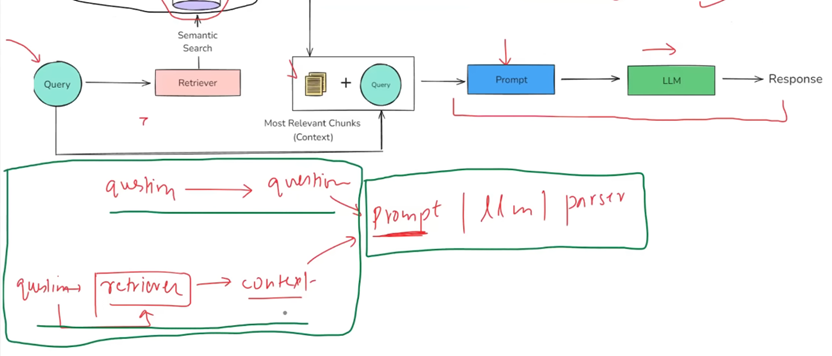

There will be 2 chains here:


1. Parallel chain : made of 2 chains


2. Prompt | LLM | Parser 
    - Prompt needs 2 things : question and context to answer
    - question is given by user which can be directly send to the LLM
    - for context : we need a retriever in which converts question into vectors and it fetches the relevant documents

In [29]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

In [30]:
def format_doc(retrived_docs): # merged the content of each document
    context_text = "\n\n".join(doc.page_content for doc in retrived_docs)
    return context_text

In [31]:
# these are the 2 parallel chains : 
parallel_chain = RunnableParallel({
    'context' : retriever | RunnableLambda(format_doc), # the relevant documents
    'question' : RunnablePassthrough() # question is paasing through as it is
})

In [ ]:
context_result = parallel_chain.invoke('What are advice to beginners he has given')
context_result

{'context': "you're one of the greatest teachers of machine learning AI ever from cs231n to today what advice would you give to beginners interested in getting into machine learning beginners are often focused on like what to do and I think the focus should be more like how much you do so I I'm kind of like believer on a high level in this 10 000 hours kind of concept where you just kind of have to just pick the things where you can spend time and you you care about and you're interested in you literally have to put in 10 000 hours of work um it doesn't even like matter as much like where you put it and you'll iterate and you'll improve and you'll waste some time I don't know if there's a better way you need to put in 10 000 hours but I think it's actually really nice because I feel like there's some sense of determinism about being an expert at a thing if you spend ten thousand hours you can literally pick an arbitrary thing and I think if you spend ten thousand hours of deliberate ef

In [ ]:
context_result['question'] # extarcting question from context

'What are advice to beginners he has given'

In [ ]:
context_result['context']

"you're one of the greatest teachers of machine learning AI ever from cs231n to today what advice would you give to beginners interested in getting into machine learning beginners are often focused on like what to do and I think the focus should be more like how much you do so I I'm kind of like believer on a high level in this 10 000 hours kind of concept where you just kind of have to just pick the things where you can spend time and you you care about and you're interested in you literally have to put in 10 000 hours of work um it doesn't even like matter as much like where you put it and you'll iterate and you'll improve and you'll waste some time I don't know if there's a better way you need to put in 10 000 hours but I think it's actually really nice because I feel like there's some sense of determinism about being an expert at a thing if you spend ten thousand hours you can literally pick an arbitrary thing and I think if you spend ten thousand hours of deliberate effort and wor

In [33]:
parser = StrOutputParser() # as we need output as string

In [34]:
main_chain = parallel_chain | prompt | llm | parser # connecting the parallel chain and this chain to fetch results from LLM

In [35]:
main_chain.invoke('Can you summarize the video')

"- The speaker discusses the challenges of creating educational content, noting that it can take about 10 hours to produce one hour of engaging material.\n- They emphasize the importance of revisiting basic concepts like back propagation and loss functions, which helps strengthen their understanding.\n- Teaching is described as a way to identify gaps in knowledge, as explaining concepts can reveal areas of uncertainty.\n- The speaker mentions the iterative process of content creation, including multiple takes and the need to delete sections that don't fit well.\n- They highlight the value of building concepts live, using coding as a practical demonstration of theories.\n- Overall, creating high-quality educational content is portrayed as a difficult but rewarding endeavor."

## Improvements

Here’s a one-liner for each item, focused on making a RAG system production-ready:

## UI-based Enhancements

* Build a clean chat UI with citations, copy/share, feedback buttons, error states, and trace links so users trust, understand, and control answers.

## 1. Evaluation

* **Ragas (Evaluates the RAG):** Automated metrics (faithfulness, answer/context relevance, retrieval precision/recall) to spot weaknesses fast.
* **LangSmith:** Production-grade tracing, eval runs, prompt/version management, and run comparisons to iterate safely.

## 2. Indexing

* **Document Ingestion:** Robust pipelines to fetch, clean, dedupe, enrich metadata, and timestamp documents.
* **Text Splitting:** Structure- and semantics-aware chunking with overlap to preserve coherence and boost recall.
* **Vector Store:** Use cloud based databases like PINECONE.

## 3. Retrieval

### a. Pre-Retrieval

* **Query rewriting using LLM:** Rephrase/clarify the query from user to match document language and intent.
* **Multi-query generation:** Spawn diverse sub-queries to cover facets and reduce misses.
* **Domain-aware routing:** Auto-route queries to the right index/tool based on domain or intent.

### b. During Retrieval

* **MMR (Maximal Marginal Relevance):** Balance relevance with diversity by penalizing redundancy.
* **Hybrid Retrieval:** Fuse lexical (BM25) and vector scores for better coverage and precision.
* **Reranking:** Re-score candidates with cross-encoders/LLMs for fine-grained relevance.

### c. Post-Retrieval

* **Contextual Compression:** Extract/summarize key spans to fit context limits without losing signal.

## 4. Augmentation

* **Prompt Templating:** Structured prompts with roles, instructions, and slotted context/citations.
* **Answer grounding:** Constrain generation to retrieved sources and require citations.
* **Context window optimization:** Deduplicate, order, and pack chunks budget-aware for maximal utility.

## 5. Generation

* **Answer with Citation:** Inline, verifiable citations linked to exact passages for trust and debugging.
* **Guard-railing:** Safety filters, schema/JSON enforcement, and tool whitelists to prevent off-policy outputs.

## 6. System Design

* **Multimodal:** Support text+images/audio/PDFs in embedding, retrieval, and answers.
* **Agentic:** Orchestrate multi-step tool use (search, browse, code, calc) with planning and retries.
* **Memory-based:** user/session memory and facts to personalize responses and reduce re-retrieval.
